## Shap

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib

xgb_model = joblib.load("../models/xgb_creditrisk.pkl")

test = pd.read_parquet("../data/test_processed.parquet")
TARGET   = "default"
FEATURES = [c for c in test.columns if c != TARGET]

X_test = test[FEATURES]

print(f"shap version : {shap.__version__}")
print(f"X_test shape : {X_test.shape}")

c:\Users\Rolando\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap version : 0.51.0
X_test shape : (97761, 39)


In [2]:
# Celda 2 — Calcular SHAP values (puede tardar 2-3 min)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

print("SHAP values calculados ✓")
print(f"Shape shap_values : {shap_values.values.shape}")

SHAP values calculados ✓
Shape shap_values : (97761, 39)


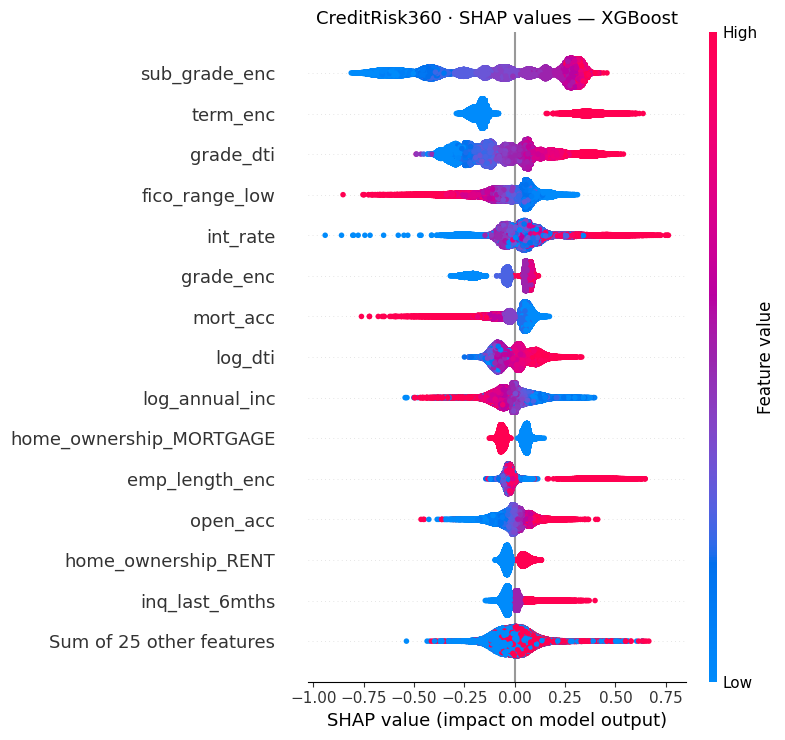

In [3]:
# Beeswarm plot (importante)
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("CreditRisk360 · SHAP values — XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

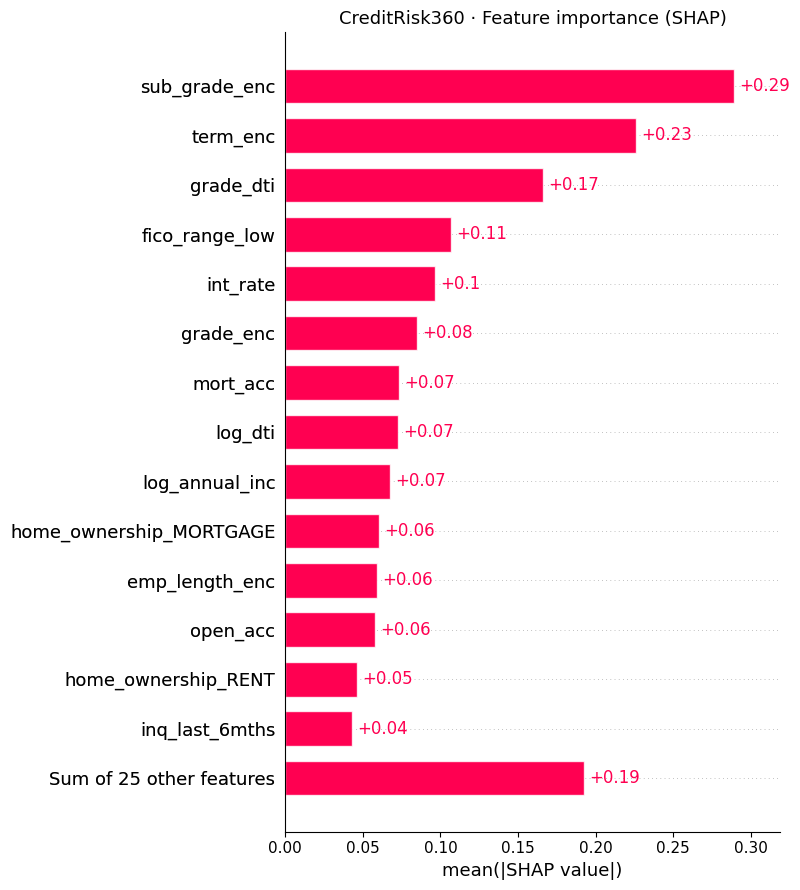

In [4]:
# Bar plot (importancia global)
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("CreditRisk360 · Feature importance (SHAP)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

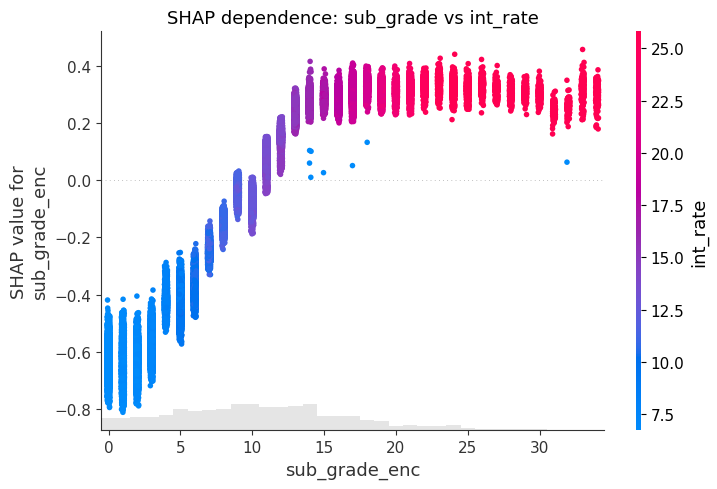

In [5]:
# Dependence plot: sub_grade vs int_rate
plt.figure()
shap.plots.scatter(shap_values[:, "sub_grade_enc"], 
                   color=shap_values[:, "int_rate"],
                   show=False)
plt.title("SHAP dependence: sub_grade vs int_rate", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/shap_dependence_subgrade.png", dpi=150, bbox_inches="tight")
plt.show()

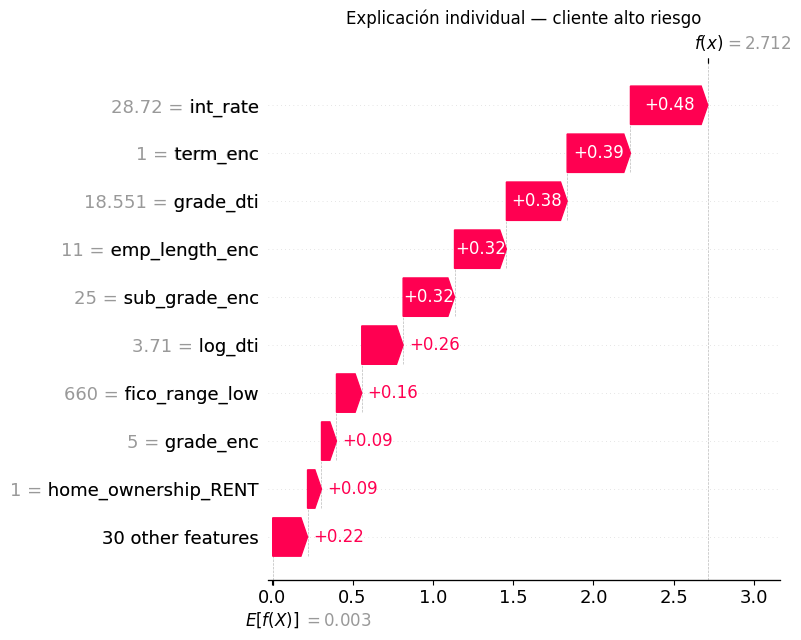

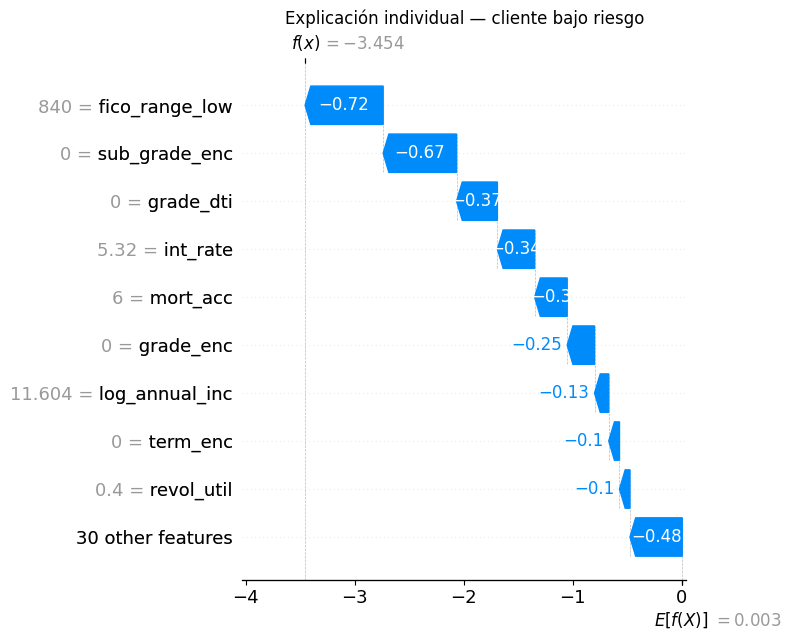

In [6]:
# Waterfall plot: cliente de alto riesgo vs bajo riesgo
# Cliente más riesgoso
idx_high = np.argmax(shap_values.values.sum(axis=1))
plt.figure()
shap.plots.waterfall(shap_values[idx_high], show=False)
plt.title("Explicación individual — cliente alto riesgo", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/shap_waterfall_high.png", dpi=150, bbox_inches="tight")
plt.show()

# Cliente menos riesgoso
idx_low = np.argmin(shap_values.values.sum(axis=1))
plt.figure()
shap.plots.waterfall(shap_values[idx_low], show=False)
plt.title("Explicación individual — cliente bajo riesgo", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/shap_waterfall_low.png", dpi=150, bbox_inches="tight")
plt.show()